In [1]:
import pyvisa

In [ ]:
import pyvisa

rm = pyvisa.ResourceManager()
scope = rm.open_resource('GPIB0::2::INSTR')
scope.timeout = 5000

print("="*60)
print("QUERYING TRIGGER PARAMETERS")
print("="*60)

# List of trigger query commands to try
trigger_queries = [
    # Basic trigger info
    ('Trigger Type', 'TRIGGER:A:TYPE?'),
    ('Trigger Mode', 'TRIGGER:A:MODE?'),

    # Edge trigger specific
    ('Edge Source', 'TRIGGER:A:EDGE:SOURCE?'),
    ('Edge Slope', 'TRIGGER:A:EDGE:SLOPE?'),
    ('Edge Coupling', 'TRIGGER:A:EDGE:COUPLING?'),

    # Trigger level queries (multiple formats to try)
    ('Level (format 1)', 'TRIGGER:A:LEVEL?'),
    ('Level (format 2)', 'TRIGGER:A:LEVEL:CH1?'),
    ('Level CH1 (format 3)', 'TRIGGER:A:LEVEL:CH1?'),
    ('Level (format 4)', 'TRIGGER:LEVEL?'),

    # Holdoff
    ('Holdoff Time', 'TRIGGER:A:HOLDOFF:TIME?'),

    # Position
    ('Horizontal Position', 'HORIZONTAL:TRIGGER:POSITION?'),
]

print("\nTesting trigger queries...\n")

working_commands = {}

for description, command in trigger_queries:
    print(f"{description:30s} ({command})")
    try:
        result = scope.query(command).strip()
        print(f"  ✓ Result: {result}")
        working_commands[description] = (command, result)
    except pyvisa.errors.VisaIOError as e:
        if 'TMO' in str(e):
            print(f"  ✗ Timeout")
        else:
            print(f"  ✗ Error: {e}")
    except Exception as e:
        print(f"  ✗ Error: {type(e).__name__}")
    print()

# Summary
print("="*60)
print("WORKING COMMANDS SUMMARY")
print("="*60)
for desc, (cmd, result) in working_commands.items():
    print(f"{desc:30s}: {result}")

scope.close()

In [ ]:
import pyvisa
import numpy as np
import matplotlib.pyplot as plt
import time

class ScopeDataTest:
    """Test data acquisition from TDS 6604"""

    def __init__(self, scope_gpib='GPIB0::1::INSTR'):
        """Connect to scope"""
        self.rm = pyvisa.ResourceManager()
        self.scope = self.rm.open_resource(scope_gpib)
        self.scope.timeout = 30000

        idn = self.scope.query('*IDN?')
        print(f"✓ Connected: {idn.strip()}\n")

    def setup_for_test(self):
        """Setup scope for test acquisition"""
        print("="*70)
        print("CONFIGURING SCOPE")
        print("="*70 + "\n")

        print("1. Channel:")
        self.scope.write('SELECT:CH1 ON')
        self.scope.write('CH1:SCALE 1')
        self.scope.write('CH1:POSITION 0')
        self.scope.write('CH1:COUPLING DC')
        print("   CH1: 1V/div, DC coupled")

        print("\n2. Timebase:")
        self.scope.write('HORIZONTAL:MAIN:SCALE 1E-6')  # 1μs/div
        self.scope.write('HORIZONTAL:MAIN:POSITION 50')  # Centered
        print("   1μs/div, trigger centered")

        print("\n3. Record length:")
        self.scope.write('HORIZONTAL:RECORDLENGTH 10000')
        actual = int(float(self.scope.query('HORIZONTAL:RECORDLENGTH?').strip()))
        print(f"   {actual} points")

        print("\n4. Trigger:")
        self.scope.write('TRIGGER:A:TYPE EDGE')
        self.scope.write('TRIGGER:A:EDGE:SOURCE CH1')
        self.scope.write('TRIGGER:A:EDGE:SLOPE RISE')
        self.scope.write('TRIGGER:A:LEVEL 0.0')  # 0V - triggers easily
        self.scope.write('TRIGGER:A:MODE NORMAL')
        print("   CH1, rising, 0V, normal")

        print("\n5. Acquisition:")
        self.scope.write('ACQUIRE:MODE SAMPLE')
        self.scope.write('ACQUIRE:STOPAFTER SEQUENCE')
        print("   Sample, single sequence")

        print("\n✓ Configured")
        print("="*70)

    def capture_with_force_trigger(self):
        """Capture using software force trigger"""
        print("\n" + "="*70)
        print("CAPTURE WITH SOFTWARE FORCE TRIGGER")
        print("="*70)
        print("\nThis will capture whatever is on CH1 right now")
        print("(Even if just noise - that's fine for testing)\n")

        input("Press Enter to capture...")

        print("\n⏳ Starting acquisition...")

        # Stop any current acquisition
        self.scope.write('ACQUIRE:STATE OFF')
        time.sleep(0.1)

        # Start single sequence acquisition
        self.scope.write('ACQUIRE:STOPAFTER SEQUENCE')
        self.scope.write('ACQUIRE:STATE RUN')
        time.sleep(0.2)

        print("   Scope armed")

        # Force trigger via software
        print("   Forcing trigger via software...")
        self.scope.write('TRIGGER FORCE')

        # Wait for acquisition to complete
        time.sleep(0.5)

        # Check state
        max_wait = 5
        start = time.time()

        while time.time() - start < max_wait:
            state = int(self.scope.query('ACQUIRE:STATE?').strip())
            if state == 0:
                print("   ✓ Acquisition complete!")
                return True
            time.sleep(0.1)

        # Even if state isn't 0, data might be available
        print("   ⚠ Timeout waiting for state, but trying to get data anyway...")
        return True

    def get_waveform_data(self):
        """Retrieve waveform - FIXED VERSION"""
        print("\n" + "="*70)
        print("RETRIEVING WAVEFORM DATA")
        print("="*70 + "\n")

        try:
            # Configure data transfer
            print("1. Configuring data transfer...")
            self.scope.write('DATA:SOURCE CH1')
            self.scope.write('DATA:ENCDG RIBINARY')
            self.scope.write('DATA:WIDTH 2')
            self.scope.write('DATA:START 1')

            # Get record length
            record_length = int(float(self.scope.query('HORIZONTAL:RECORDLENGTH?').strip()))
            self.scope.write(f'DATA:STOP {record_length}')
            print(f"   Record length: {record_length} points")

            # Get scaling parameters individually
            print("\n2. Getting scaling parameters...")

            x_incr = float(self.scope.query('WFMPRE:XINCR?').strip())
            x_zero = float(self.scope.query('WFMPRE:XZERO?').strip())
            y_mult = float(self.scope.query('WFMPRE:YMULT?').strip())
            y_zero = float(self.scope.query('WFMPRE:YZERO?').strip())
            y_off = float(self.scope.query('WFMPRE:YOFF?').strip())

            print(f"   X increment: {x_incr*1e9:.3f} ns/point")
            print(f"   Y multiplier: {y_mult*1e3:.3f} mV/count")

            # Request waveform
            print("\n3. Requesting waveform...")
            self.scope.write('CURVE?')

            print("4. Reading binary data...")
            raw_data = self.scope.read_raw()
            print(f"   Received {len(raw_data)} bytes")

            # Parse binary header: #<x><yyy><data>
            print("\n5. Parsing...")
            header_len = 2 + int(chr(raw_data[1]))
            byte_count = int(raw_data[2:header_len].decode('ascii'))
            data_bytes = raw_data[header_len:header_len + byte_count]

            print(f"   Data: {byte_count} bytes = {byte_count//2} points")

            # Convert to voltage
            print("\n6. Converting to voltage...")
            voltage_raw = np.frombuffer(data_bytes, dtype=np.dtype('>i2'))
            voltage = (voltage_raw - y_off) * y_mult + y_zero

            # Time array
            time_array = np.arange(len(voltage)) * x_incr + x_zero

            # Stats
            print(f"   ✓ {len(voltage)} points")
            print(f"\n7. Waveform stats:")
            print(f"   Time: {time_array[0]*1e6:.3f} to {time_array[-1]*1e6:.3f} μs")
            print(f"   Voltage: {voltage.min():.3f} to {voltage.max():.3f} V")
            print(f"   Mean: {voltage.mean():.3f} V")

            print("\n✓ Success!")
            print("="*70)

            return {
                'time': time_array,
                'voltage': voltage,
                'points': len(voltage)
            }

        except Exception as e:
            print(f"\n✗ Error: {e}")
            import traceback
            traceback.print_exc()
            return None

    def save_waveform(self, waveform, filename='waveform.csv'):
        """Save waveform to CSV with metadata header"""
        if waveform is None:
            return

        print(f"\n💾 Saving to {filename}...")

        # Gather metadata from scope
        try:
            metadata = self._get_scope_metadata()
        except:
            metadata = {}

        # Create header with metadata
        header_lines = []
        header_lines.append("TDS 6604 Waveform Data")
        header_lines.append(f"Captured: {time.strftime('%Y-%m-%d %H:%M:%S')}")
        header_lines.append("")

        # Add metadata
        header_lines.append("SCOPE SETTINGS:")
        for key, value in metadata.items():
            header_lines.append(f"  {key}: {value}")

        header_lines.append("")
        header_lines.append("WAVEFORM STATISTICS:")
        header_lines.append(f"  Points: {waveform['points']}")
        header_lines.append(f"  Time range: {waveform['time'][0]*1e6:.6f} to {waveform['time'][-1]*1e6:.6f} us")
        header_lines.append(f"  Min voltage: {waveform['voltage'].min():.6f} V")
        header_lines.append(f"  Max voltage: {waveform['voltage'].max():.6f} V")
        header_lines.append(f"  Mean voltage: {waveform['voltage'].mean():.6f} V")
        header_lines.append(f"  RMS voltage: {np.sqrt(np.mean(waveform['voltage']**2)):.6f} V")
        header_lines.append("")
        header_lines.append("DATA:")
        header_lines.append("Time (s), Voltage (V)")

        # Combine into single header string
        header = '\n'.join(header_lines)

        # Save data
        data = np.column_stack((waveform['time'], waveform['voltage']))
        np.savetxt(filename, data, delimiter=',', header=header, comments='# ')

        print(f"✓ Saved {len(waveform['voltage'])} points with metadata")

    def _get_scope_metadata(self):
        """Gather scope configuration metadata"""
        metadata = {}

        try:
            # Identification
            metadata['Instrument'] = self.scope.query('*IDN?').strip()

            # Channel settings
            ch_scale = self.scope.query('CH1:SCALE?').strip()
            ch_position = self.scope.query('CH1:POSITION?').strip()
            ch_coupling = self.scope.query('CH1:COUPLING?').strip()
            ch_bw = self.scope.query('CH1:BANDWIDTH?').strip()

            metadata['CH1 Scale'] = f"{float(ch_scale)} V/div"
            metadata['CH1 Position'] = f"{float(ch_position)} div"
            metadata['CH1 Coupling'] = ch_coupling
            metadata['CH1 Bandwidth'] = ch_bw

            # Horizontal settings
            h_scale = self.scope.query('HORIZONTAL:MAIN:SCALE?').strip()
            h_position = self.scope.query('HORIZONTAL:MAIN:POSITION?').strip()
            record_length = self.scope.query('HORIZONTAL:RECORDLENGTH?').strip()

            metadata['Timebase'] = f"{float(h_scale)*1e9:.3f} ns/div"
            metadata['Horizontal Position'] = f"{float(h_position)} %"
            metadata['Record Length'] = f"{int(float(record_length))} points"

            # Acquisition settings
            acq_mode = self.scope.query('ACQUIRE:MODE?').strip()
            metadata['Acquisition Mode'] = acq_mode

            # Trigger settings
            try:
                trig_source = self.scope.query('TRIGGER:A:EDGE:SOURCE?').strip()
                trig_slope = self.scope.query('TRIGGER:A:EDGE:SLOPE?').strip()
                trig_level = self.scope.query('TRIGGER:A:LEVEL?').strip()
                trig_mode = self.scope.query('TRIGGER:A:MODE?').strip()

                metadata['Trigger Source'] = trig_source
                metadata['Trigger Slope'] = trig_slope
                metadata['Trigger Level'] = f"{float(trig_level)} V"
                metadata['Trigger Mode'] = trig_mode
            except:
                pass

            # Waveform parameters
            x_incr = self.scope.query('WFMPRE:XINCR?').strip()
            y_mult = self.scope.query('WFMPRE:YMULT?').strip()

            metadata['Sample Interval'] = f"{float(x_incr)*1e9:.6f} ns"
            metadata['Voltage Resolution'] = f"{float(y_mult)*1e6:.6f} uV/count"

        except Exception as e:
            print(f"  (Warning: Could not retrieve all metadata: {e})")

        return metadata

    def plot_waveform(self, waveform):
        """Plot waveform"""
        if waveform is None:
            return

        print("\n\Plotting...")

        fig, ax = plt.subplots(figsize=(12, 6))
        ax.plot(waveform['time'] * 1e6, waveform['voltage'], 'b-', linewidth=0.5)
        ax.set_xlabel('Time (μs)')
        ax.set_ylabel('Voltage (V)')
        ax.set_title(f'TDS 6604 Waveform ({waveform["points"]} points)')
        ax.grid(True)

        plt.tight_layout()
        plt.savefig('waveform_plot.png', dpi=150)
        print("Saved to waveform_plot.png")

        try:
            plt.show()
        except:
            print("  (Display not available - saved to file)")

    def close(self):
        """Close connection"""
        self.scope.close()
        self.rm.close()
        print("\n✓ Connection closed")


In [24]:
import pyvisa
import numpy as np

rm = pyvisa.ResourceManager()
scope = rm.open_resource('GPIB0::1::INSTR')
scope.write('DATA:START 1')
record_length=100000
scope.write(f'DATA:STOP {record_length}')

scope.write('CURVE?')
raw_data = scope.read_raw()

header_len = 2 + int(chr(raw_data[1]))
byte_count = int(raw_data[2:header_len].decode('ascii'))
data_bytes = raw_data[header_len:header_len + byte_count]

voltage_raw = np.frombuffer(data_bytes, dtype=np.dtype('>i2'))


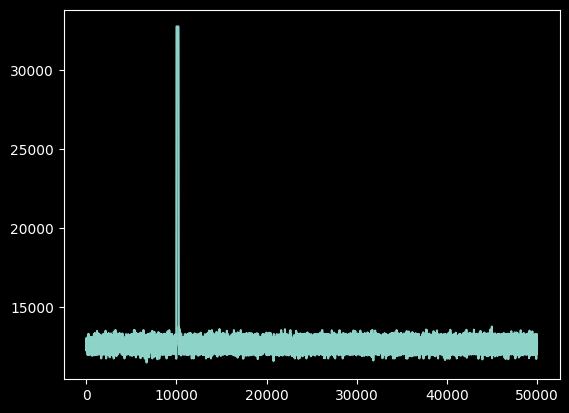

In [25]:
import matplotlib.pyplot as plt
plt.plot(voltage_raw)

In [ ]:
import pyvisa
import time
import numpy as np
import matplotlib.pyplot as plt

def debug_burst_mode():
    """Debug burst mode with long pulse and CH1 triggering"""

    print("\n" + "="*60)
    print("BURST MODE DEBUG")
    print("="*60 + "\n")

    print("Hardware connections:")
    print("  1. Pulser CH1 → Scope CH1")
    input("\nPress Enter when ready...")

    # Connect
    rm = pyvisa.ResourceManager()
    # pulser = rm.open_resource('TCPIP::169.254.125.69::INSTR')
    pulser = rm.open_resource('TCPIP::169.254.209.156::INSTR') #Kepler pulser
    pulser.timeout = 10000
    scope = rm.open_resource('GPIB0::1::INSTR')#changed to 1 from 2
    scope.timeout = 10000



    print(f"\nPulser: {pulser.query('*IDN?').strip()}")
    print(f"Scope:  {scope.query('*IDN?').strip()}\n")

    # Setup pulser for burst mode with LONG pulse
    print("="*60)
    print("CONFIGURING PULSER FOR BURST MODE")
    print("="*60 + "\n")

    pulser.write('PULSEGENCONTROL:STOP')
    pulser.write('OUTPUT1:STATE OFF')
    time.sleep(0.3)

    # Use a LONG pulse that's easy to see
    PULSE_WIDTH_MS = 100  # 100 milliseconds = very long and visible

    print("1. Basic pulse settings:")
    pulser.write('SOURCE1:VOLTAGE:LEVEL 1.0')
    pulser.write('SOURCE1:VOLTAGE:OFFSET 0.5')
    pulser.write(f'SOURCE1:PULSE:WIDTH {PULSE_WIDTH_MS}E-3')  # 100 ms
    pulser.write('SOURCE1:FREQUENCY 1')  # Doesn't matter in burst
    pulser.write('SOURCE1:INV OFF')
    print(f"   Width: {PULSE_WIDTH_MS} ms (very long!)")
    print(f"   Amplitude: 0 to 1V")

    print("\n2. Burst mode settings:")
    pulser.write('SOURCE1:BURST:NCYCLES 1')  # 1 pulse per trigger
    pulser.write('TRIGGER:MODE BURST')
    pulser.write('TRIGGER:SOURCE MANUAL')
    time.sleep(0.2)

    # Verify burst settings
    burst_cycles = pulser.query('SOURCE1:BURST:NCYCLES?').strip()
    trig_mode = pulser.query('TRIGGER:MODE?').strip()
    trig_source = pulser.query('TRIGGER:SOURCE?').strip()

    print(f"   Burst cycles: {burst_cycles}")
    print(f"   Trigger mode: {trig_mode}")
    print(f"   Trigger source: {trig_source}")

    print("\n3. Enabling output and starting:")
    pulser.write('OUTPUT1:STATE ON')
    output_state = pulser.query('OUTPUT1:STATE?').strip()
    print(f"   Output state: {output_state}")

    pulser.write('PULSEGENCONTROL:START')
    time.sleep(0.5)
    print("   ✓ Pulse generator started and armed")

    # Setup scope
    print("\n" + "="*60)
    print("CONFIGURING SCOPE")
    print("="*60 + "\n")

    scope.write('SELECT:CH1 ON')
    scope.write('CH1:SCALE 0.5')  # 0.5 V/div
    scope.write('CH1:POSITION -1')
    scope.write('CH1:COUPLING DC')
    scope.write('HORIZONTAL:MAIN:SCALE 20E-3')  # 20 ms/div for 100ms pulse
    scope.write('HORIZONTAL:MAIN:POSITION 10')

    scope.write('TRIGGER:A:TYPE EDGE')
    scope.write('TRIGGER:A:EDGE:SOURCE CH1')
    scope.write('TRIGGER:A:EDGE:SLOPE RISE')
    scope.write('TRIGGER:A:LEVEL:CH1 0.5')
    scope.write('TRIGGER:A:MODE NORMAL')

    scope.write('ACQUIRE:STOPAFTER SEQUENCE')
    scope.write('ACQUIRE:MODE SAMPLE')

    print("✓ Scope configured")
    print("  Trigger on CH1 rising edge")
    print("  100ms pulse should be easy to capture\n")

    # Now test different trigger scenarios
    print("="*60)
    print("TEST 1: Basic *TRG command")
    print("="*60 + "\n")

    print("Arming scope...")
    scope.write('ACQUIRE:STATE RUN')
    time.sleep(0.3)
    print("✓ Scope armed and waiting\n")

    print("Sending *TRG to pulser...")
    input("Press Enter to trigger...")
    pulser.write('*TRG')
    print("✓ *TRG sent")

    # Check pulser front panel
    print("\n⚠ CHECK PULSER FRONT PANEL:")
    print("   Do you see the trigger indicator light up? (y/n): ", end='')
    trigger_light = input()

    # Wait for scope
    print("\nWaiting for scope to capture (5 seconds)...")
    start = time.time()
    captured = False
    while time.time() - start < 5:
        state = int(scope.query('ACQUIRE:STATE?').strip())
        if state == 0:
            print("✓✓✓ SCOPE CAPTURED!\n")
            captured = True
            break
        time.sleep(0.1)

    if not captured:
        print("✗ Scope did not capture\n")

    # Analyze results
    print("="*60)
    print("RESULTS - TEST 1")
    print("="*60 + "\n")

    if trigger_light.lower() == 'y' and captured:
        print("✓✓✓ SUCCESS!")
        print("   Trigger light: YES")
        print("   Scope captured: YES")
        print("   → Burst mode is working!\n")

    elif trigger_light.lower() == 'y' and not captured:
        print("⚠ PARTIAL SUCCESS")
        print("   Trigger light: YES (pulser thinks it triggered)")
        print("   Scope captured: NO (no pulse actually generated)")
        print("   → Pulser acknowledges trigger but doesn't output pulse\n")
        print("Possible issues:")
        print("   1. Missing enable/arm command")
        print("   2. Output not actually active in burst mode")
        print("   3. Burst mode requires different output routing")

    else:
        print("✗ TRIGGER NOT WORKING")
        print("   Trigger light: NO")
        print("   Scope captured: NO")
        print("   → *TRG command not triggering burst\n")

    # If first test failed, try alternatives
    if not captured:
        print("\n" + "="*60)
        print("TEST 2: Alternative trigger commands")
        print("="*60 + "\n")

        alternative_commands = [
            'TRIGGER:EXECUTE',
            'TRIGGER:INITIATE',
            'BURST:EXECUTE',
            'BURST:TRIGGER',
            'BURST:INITIATE',
            'SOURCE1:BURST:TRIGGER',
            'SOURCE1:TRIGGER:EXECUTE',
        ]

        for cmd in alternative_commands:
            print(f"\nTrying: {cmd}")

            # Arm scope
            scope.write('ACQUIRE:STATE RUN')
            time.sleep(0.3)

            input("  Press Enter to try this command...")

            try:
                pulser.write(cmd)
                print(f"  Command sent")

                # Wait for scope
                time.sleep(0.5)
                state = int(scope.query('ACQUIRE:STATE?').strip())

                if state == 0:
                    print(f"  ✓✓✓ SUCCESS! Command: {cmd}")
                    captured = True
                    break
                else:
                    print(f"  ✗ No capture")

            except Exception as e:
                print(f"  Error: {e}")

    # If still not captured, check if pulse is even possible
    if not captured:
        print("\n" + "="*60)
        print("TEST 3: Check if output is actually enabled")
        print("="*60 + "\n")

        print("Querying pulser status...")
        queries = [
            'OUTPUT1:STATE?',
            'SOURCE1:BURST:STATE?',
            'TRIGGER:MODE?',
            'SYSTEM:STATUS?',
        ]

        for query in queries:
            try:
                result = pulser.query(query).strip()
                print(f"  {query:<30} → {result}")
            except:
                print(f"  {query:<30} → (not supported)")
            time.sleep(0.1)

        print("\n⚠ Burst mode may require additional setup")
        print("   Check manual for:")
        print("   1. Burst enable/arm command")
        print("   2. Output routing in burst mode")
        print("   3. Status registers indicating armed state")

    # If captured, get the waveform
    if captured:
        print("\n" + "="*60)
        print("RETRIEVING WAVEFORM")
        print("="*60 + "\n")

        scope.write('DATA:SOURCE CH1')
        scope.write('DATA:ENCDG RIBINARY')
        scope.write('DATA:WIDTH 2')

        x_incr = float(scope.query('WFMPRE:XINCR?').strip())
        x_zero = float(scope.query('WFMPRE:XZERO?').strip())
        y_mult = float(scope.query('WFMPRE:YMULT?').strip())
        y_zero = float(scope.query('WFMPRE:YZERO?').strip())
        y_off = float(scope.query('WFMPRE:YOFF?').strip())

        scope.write('CURVE?')
        raw_data = scope.read_raw()

        header_len = 2 + int(chr(raw_data[1]))
        byte_count = int(raw_data[2:header_len].decode('ascii'))
        data_bytes = raw_data[header_len:header_len + byte_count]

        voltage_raw = np.frombuffer(data_bytes, dtype=np.dtype('>i2'))
        voltage = (voltage_raw - y_off) * y_mult + y_zero
        time_array = np.arange(len(voltage)) * x_incr + x_zero

        print(f"✓ Got {len(voltage)} points")
        print(f"  Voltage: {voltage.min():.3f} to {voltage.max():.3f} V")

        # Measure pulse width
        threshold = 0.5
        high_indices = np.where(voltage > threshold)[0]
        if len(high_indices) > 1:
            pulse_width_measured = (high_indices[-1] - high_indices[0]) * x_incr
            print(f"  Measured pulse width: {pulse_width_measured*1e3:.1f} ms")
            print(f"  Expected: {PULSE_WIDTH_MS} ms")

        # Plot
        plt.figure(figsize=(12, 6))
        plt.plot(time_array*1e3, voltage, linewidth=1)
        plt.axhline(y=0, color='k', linestyle='--', linewidth=0.5, alpha=0.3)
        plt.axhline(y=1.0, color='r', linestyle='--', linewidth=0.5, alpha=0.3)
        plt.axhline(y=0.5, color='g', linestyle=':', linewidth=0.5, alpha=0.5, label='Trigger level')
        plt.xlabel('Time (ms)')
        plt.ylabel('Voltage (V)')
        plt.title('Burst Mode Pulse Capture')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.savefig('burst_mode_debug.png', dpi=150)
        print("\n✓ Saved to burst_mode_debug.png")
        plt.show()

    # Cleanup
    print("\n" + "="*60)
    print("CLEANUP")
    print("="*60 + "\n")

    pulser.write('OUTPUT1:STATE OFF')
    pulser.write('PULSEGENCONTROL:STOP')
    pulser.close()
    scope.close()
    rm.close()

    print("✓ Debug complete\n")

    if captured:
        print("="*60)
        print("BURST MODE IS WORKING!")
        print("="*60)
    else:
        print("="*60)
        print("BURST MODE NOT WORKING - USE CONTINUOUS MODE WORKAROUND")
        print("="*60)


if __name__ == "__main__":
    debug_burst_mode()

In [2]:
# scope impedence
import pyvisa

rm = pyvisa.ResourceManager()
pulser = rm.open_resource('TCPIP::169.254.125.69::INSTR')
scope = rm.open_resource('GPIB0::2::INSTR')

print("=== IMPEDANCE CHECK ===\n")

# Check pulser
print("Pulser queries:")
pulser_queries = [
    'OUTPUT1:IMPEDANCE?',
    'SOURCE1:OUTPUT:IMPEDANCE?',
    'SOURCE1:LOAD?',
    'OUTPUT1:LOAD?',
]

for q in pulser_queries:
    try:
        result = pulser.query(q).strip()
        print(f"  {q:<35} → {result}")
    except:
        pass

print("\nScope queries:")
scope_queries = [
    'CH1:IMPEDANCE?',
    'CH1:TERMINATION?',
    'CH4:IMPEDANCE?',
    'CH4:TERMINATION?',
]

for q in scope_queries:
    try:
        result = scope.query(q).strip()
        print(f"  {q:<35} → {result}")
    except:
        pass

print("\n=== TRYING TO SET 50 OHM ===\n")

commands = [
    'CH1:IMPEDANCE FIFTY',
    'CH1:TERMINATION FIFTY',
    'CH1:IMPEDANCE 50',
]

for cmd in commands:
    try:
        scope.write(cmd)
        time.sleep(0.1)
        # Try to read back
        result = scope.query('CH1:IMPEDANCE?').strip()
        print(f"✓ {cmd:<35} → {result}")
    except Exception as e:
        print(f"✗ {cmd:<35} → {e}")

pulser.close()
scope.close()
rm.close()

=== IMPEDANCE CHECK ===

Pulser queries:
  OUTPUT1:IMPEDANCE?                  → 
  SOURCE1:OUTPUT:IMPEDANCE?           → 
  SOURCE1:LOAD?                       → 
  OUTPUT1:LOAD?                       → 

Scope queries:
  CH1:IMPEDANCE?                      → FIFTY
  CH1:TERMINATION?                    → 50.0000
  CH4:IMPEDANCE?                      → FIFTY
  CH4:TERMINATION?                    → 50.0000

=== TRYING TO SET 50 OHM ===

✗ CH1:IMPEDANCE FIFTY                 → name 'time' is not defined
✗ CH1:TERMINATION FIFTY               → name 'time' is not defined
✗ CH1:IMPEDANCE 50                    → name 'time' is not defined


In [5]:
import pyvisa
import time

rm = pyvisa.ResourceManager()
pulser = rm.open_resource('TCPIP::169.254.125.69::INSTR')
scope = rm.open_resource('GPIB0::2::INSTR')

print("Setting to matched 50Ω...\n")

# Set pulser to 50Ω
pulser.write('SOUR1:LOAD:IMP 50')
time.sleep(0.2)
pulser_imp = pulser.query('SOUR1:LOAD:IMP?').strip()
print(f"Pulser CH1: {pulser_imp}")

# Set scope to 50Ω
scope.write('CH1:IMPEDANCE FIFTY')
scope.write('CH4:IMPEDANCE FIFTY')
time.sleep(0.2)
scope_ch1 = scope.query('CH1:IMPEDANCE?').strip()
scope_ch4 = scope.query('CH4:IMPEDANCE?').strip()
print(f"Scope CH1: {scope_ch1}")
print(f"Scope CH4: {scope_ch4}")

print("\n✓ Both set to 50Ω - should see clean pulses now")

pulser.close()
scope.close()
rm.close()

Setting to matched 50Ω...

Pulser CH1: 50
Scope CH1: FIFTY
Scope CH4: FIFTY

✓ Both set to 50Ω - should see clean pulses now
